# FS→DSA Austria — Exact Baseline Workflow

Purpose: Guarantee that all scenarios start from the same NFPC baseline and that a scenario with zero SPB change reproduces the NFPC DSA exactly, while any SPB change triggers endogenous responses.

Outline:
- Step 1: Exact NFPC replication from Table 17 (levels and growth) — produces `baseline_model`.
- Step 1b: Freeze NFPC baseline counterpart arrays into a reusable `scenario_template` for all subsequent runs.
- Step 2a: Apply MTP SPB path with NFPC anchors (only SPB differs) — endogenous DSA.
- Step 2b: Find binding SPB path (optimal) using the same NFPC anchors.
- Step 2c: Compare results in one chart.
- Step 3: Potential uplift with identical inflation to NFPC and recompute binding SPB.



In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Resolve project root
cwd = Path.cwd()
project_root = cwd if (cwd / '03_Modell').exists() else cwd.parent
sys.path.extend([
    str((project_root / '03_Modell').parent),
    str(project_root / '03_Modell' / 'EU_DSA' / 'code' / 'classes')
])

from EU_DSA.code.classes import StochasticDsaModel as DSA
from FS_Model.integration import apply_mtp_anchors_to_dsa
from EU_DSA.code.functions import scenario_workflow  # New workflow functions
from FS_Model.data_functions import load_and_process_data
from FS_Model.model_equations import build_model
from FS_Model.scenario_functions import initialize_model, run_scenario_analysis
from FS_Model.integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb


START_YEAR, END_YEAR = 2024, 2041
ADJUSTMENT_START_YEAR = 2025
ADJUSTMENT_PERIOD = 7

print('Project root:', project_root)


Project root: c:\Users\dzsve\OneDrive - Dezernat Zukunft e.V\DZ-Schalte - Dokumente\2_Projekte\Fiskalpolitik\F48_EUCAM_DSA_Reformvorschlag


In [2]:
# load data and initialise FS model
AT = load_and_process_data(data_folder='02_Daten', sheet_name='Austria')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_AT = FS_model.insertModelVar(AT)
print('AT data shape:', AT.shape)

AT data shape: (84, 223)


In [3]:
# Initialize template DSA model
dsa_template = DSA(
    country='AUT',
    start_year=START_YEAR,
    end_year=END_YEAR,
    adjustment_period=ADJUSTMENT_PERIOD,
    adjustment_start_year=ADJUSTMENT_START_YEAR,
    fiscal_multiplier_type='ec'
)
dsa_template.project()
df_template = dsa_template.df(all=True)

a0 = dsa_template.adjustment_start
#a1 = dsa_template.adjustment_end
#closure_end = a1 + dsa_template.fiscal_multiplier_persistence
years = list(range(START_YEAR, END_YEAR + 1))

In [4]:
# NFPC inputs (Table 17) and MTP SPB
rg_pot_nfpc = pd.Series({
    2024: 0.4, 2025: 1.1, 2026: 1.1, 2027: 1.1, 2028: 1.1, 2029: 1.1, 2030: 1.1, 2031: 1.1,
    2032: 1.1, 2033: 1.1, 2034: 1.1, 2035: 1.1, 2036: 1.1, 2037: 1.1, 2038: 1.1, 2039: 1.1, 2040: 1.1, 2041: 1.1
}).reindex(years)

rg_nfpc = pd.Series({
    2024: -1.2, 2025: 0.6, 2026: 1.3, 2027: 1.6, 2028: 1.6, 2029: 1.6, 2030: 1.1, 2031: 1.1,
    2032: 1.1, 2033: 1.1, 2034: 1.1, 2035: 1.1, 2036: 1.1, 2037: 1.1, 2038: 1.1, 2039: 1.1, 2040: 1.1, 2041: 1.1
}).reindex(years)

rg_mtp = pd.Series({
    2024: -1.2, 2025: 0.2, 2026: 1.1, 2027: 1.5, 2028: 1.2, 2029: 1.3, 2030: 1.2, 2031: 1.2,
    2032: 1.5, 2033: 1.5, 2034: 1.5, 2035: 1.1, 2036: 1.1, 2037: 1.1, 2038: 1.1, 2039: 1.1, 2040: 1.1, 2041: 1.1
}).reindex(years)

pi_nfpc = pd.Series({
    2024: 3.1, 2025: 2.4, 2026: 2.0, 2027: 2.1, 2028: 2.1, 2029: 2.1, 2030: 2.2, 2031: 2.2,
    2032: 2.3, 2033: 2.3, 2034: 2.4, 2035: 2.3, 2036: 2.3, 2037: 2.3, 2038: 2.3, 2039: 2.3, 2040: 2.2, 2041: 2.2
}).reindex(years)

spb_target = pd.Series({
    2024: -2.4, 2025: -1.9, 2026: -1.4, 2027: -0.9, 2028: -0.3, 2029: 0.2, 2030: 0.7, 2031: 1.2,
    2032: 1.2, 2033: 1.2, 2034: 1.2, 2035: 1.2, 2036: 1.2, 2037: 1.2, 2038: 1.2, 2039: 1.2, 2040: 1.2, 2041: 1.2
}).reindex(years)


## Workflow-Anpassungen für neue scenario_workflow Funktionen

Dieses Notebook wurde angepasst, um die neuen `scenario_workflow` Funktionen zu verwenden:

### Schritt 1: NFPC Baseline erstellen
- Verwendet: `scenario_workflow.create_nfpc_baseline()`
- Vereinfachte Parameter: Nur `rg`, `rg_pot`, `pi` (keine separaten Baseline-Versionen)
- Automatische Berechnung von `output_gap_bl` über `_calc_output_gap()`

### Schritt 2a: MTP Szenario mit vorgegebenen SPB-Schritten
- Verwendet: `scenario_workflow.create_mtp_scenario()` mit `spb_steps_mtp`
- Anwendung direkter SPB-Anpassungsschritte

### Schritt 2b: Binding SPB finden
- Verwendet: `scenario_workflow.create_mtp_scenario()` mit `use_find_binding=True`
- Automatische Nutzung von `find_spb_binding()` mit allen DSA-Kriterien

### Schritt 2c: Vergleich der Szenarien
- Verwendet: `scenario_workflow.compare_scenarios()` für automatischen Vergleich

### Schritt 3: Policy-Responsive Szenario
- Verwendet: `scenario_workflow.create_policy_responsive_scenario()`
- Aktualisiert Potenzialwachstum und berechnet optimales SPB
- Automatische Neuberechnung von `output_gap_bl` nach Potenzialänderung


## Step 1 — NFPC replication (Table 17)


In [5]:
# STEP 1: Create NFPC Baseline using new workflow function
print("Step 1: Creating NFPC baseline...")
baseline_nfpc = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,
    rg_pot=rg_pot_nfpc,
    pi=pi_nfpc,
    dsa_model=dsa_template,
    spb_baseline=-2.4,
    inplace=False
)

# Verify NFPC baseline
print("\n=== NFPC Baseline Verification ===")
# Print output gap until 2034 (assume baseline_nfpc.start_year gives the first model year)
output_gap_years_range = list(range(baseline_nfpc.start_year, 2035))
print("\n=== Output gap for each year (baseline_nfpc) ===")
for i, year in enumerate(output_gap_years_range):
    if i < len(baseline_nfpc.output_gap_bl):
        print(f"Output gap in year {year}: {baseline_nfpc.output_gap_bl[i]:.4f}%")
    else:
        print(f"Output gap in year {year}: Data not available")

# Store as NFPC for compatibility with existing code
NFPC = baseline_nfpc
df_NFPC = NFPC.df(all=True)

Step 1: Creating NFPC baseline...

=== NFPC Baseline Verification ===

=== Output gap for each year (baseline_nfpc) ===
Output gap in year 2024: -1.1719%
Output gap in year 2025: -1.6607%
Output gap in year 2026: -1.4661%
Output gap in year 2027: -0.9774%
Output gap in year 2028: -0.4887%
Output gap in year 2029: 0.0000%
Output gap in year 2030: 0.0000%
Output gap in year 2031: 0.0000%
Output gap in year 2032: 0.0000%
Output gap in year 2033: 0.0000%
Output gap in year 2034: 0.0000%


## Step 2a — Apply MTP SPB (NFPC anchors; start from `scenario_template`)


In [6]:
## Step 2a — Apply MTP SPB (NFPC anchors) using new workflow function

# Calculate SPB steps from the MTP target path
spb_steps_mtp = np.zeros(ADJUSTMENT_PERIOD)
for tt in range(NFPC.adjustment_start, NFPC.adjustment_end + 1):
    yy = NFPC.start_year + tt
    spb_steps_mtp[tt - NFPC.adjustment_start] = spb_target.loc[yy] - spb_target.loc[yy - 1]

print(f"MTP SPB steps: {spb_steps_mtp}")

# Use new workflow function to create MTP scenario
print("\nCreating MTP scenario with predefined SPB steps...")
scenario_mtp, spb_steps_used, binding_spb = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    spb_steps_mtp=spb_steps_mtp,
    inplace=False
)

print(f"SPB steps used: {spb_steps_used}")

# Verify results
df_sce_mtp = scenario_mtp.df(all=True)

print('\nStep 2a: MTP SPB scenario created successfully.')

MTP SPB steps: [0.5 0.5 0.5 0.6 0.5 0.5 0.5]

Creating MTP scenario with predefined SPB steps...
SPB steps used: [0.5 0.5 0.5 0.6 0.5 0.5 0.5]

Step 2a: MTP SPB scenario created successfully.


## Step 2b — Binding SPB path from NFPC anchors


In [7]:
## Step 2b — Binding SPB path from NFPC anchors using new workflow function

print("Finding binding SPB path...")
binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,  # Use find_spb_binding method
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_mtp = binding_mtp.df(all=True)
print(f"Binding SPB target (2031): {binding_spb_target:.3f}%")
print(f"Binding SPB steps: {spb_steps_binding}")


Finding binding SPB path...
Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
SPB optimization succeeded with bounds [-10, 7.5] (adjusted 5 times)
Binding SPB target (2031): 1.058%
Binding SPB steps: [0.5        0.5        0.5        0.62448591 0.44439235 0.44439235
 0.44439235]


In [8]:
## Step 2c — Compare MTP scenarios using new workflow comparison function

print("Comparing MTP planned vs binding scenarios...")
comparison_mtp = scenario_workflow.compare_scenarios(
    scenario_mtp=scenario_mtp,
    scenario_policy=binding_mtp,  # Compare planned vs binding
    years=None  # Compare all years
)

print("\n=== Key Differences (Planned vs Binding) ===")
print(comparison_mtp[['year', 'spb_mtp', 'spb_policy', 'spb_diff', 'debt_mtp', 'debt_policy', 'debt_diff']].tail(10))


Comparing MTP planned vs binding scenarios...

=== Key Differences (Planned vs Binding) ===
    year  spb_mtp  spb_policy  spb_diff  debt_mtp  debt_policy  debt_diff
8   2032    1.200       1.058    -0.142    84.555       84.765      0.210
9   2033    1.200       1.058    -0.142    83.026       83.386      0.360
10  2034    1.200       1.058    -0.142    81.360       81.885      0.525
11  2035    1.200       1.058    -0.142    80.223       80.892      0.669
12  2036    1.200       1.058    -0.142    79.165       79.979      0.814
13  2037    1.200       1.058    -0.142    78.166       79.126      0.960
14  2038    1.200       1.058    -0.142    77.200       78.306      1.106
15  2039    1.200       1.058    -0.142    76.252       77.505      1.253
16  2040    1.200       1.058    -0.142    75.375       76.776      1.402
17  2041    1.200       1.058    -0.142    74.497       76.048      1.551


## Step 2c — Comparison chart


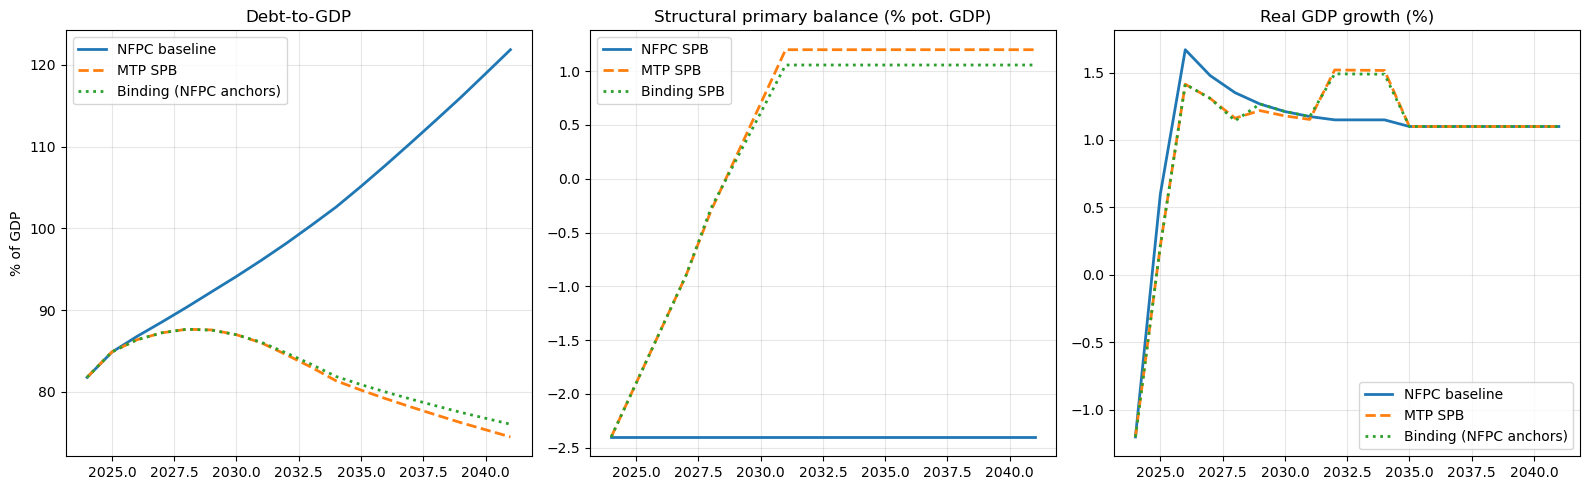

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Debt paths
ax = axes[0]
ax.plot(years, NFPC.d[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.d[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.d[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Debt-to-GDP'); ax.set_ylabel('% of GDP'); ax.grid(True, alpha=0.3); ax.legend()

# SPB
ax = axes[1]
ax.plot(years, np.full(len(years), -2.4), label='NFPC SPB', lw=2)
ax.plot(years, spb_target.values, '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.spb_bca[:len(years)], ':', label='Binding SPB', lw=2)
ax.set_title('Structural primary balance (% pot. GDP)'); ax.grid(True, alpha=0.3); ax.legend()

# Real growth
ax = axes[2]
ax.plot(years, NFPC.rg[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.rg[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.rg[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Real GDP growth (%)'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## Step 3 — Potential uplift (optional) with same inflation (NFPC)


In [10]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
measures = [
    # Measure 1: Childcare reform -> LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.014, 0.014], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
    #{ 'var': 'EPS_H', 'values': [0.0, 0.055, 0.055, 0.055], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },

    # Measure 2: Corridor pension -> LP
    { 'var': 'EPS_LP', 'values': [0.0, 0.0, 0.052, 0.052, 0.0052], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
    
    # Measure 3: Red-White-Red Card -> LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.0000, 0.0000, 0.07, 0.07], 'interpret': 'asolute', 'persist': True, 'persist_mode': 'plateau' },
]

In [11]:
# Extract paths from the binding DSA model
rg = pd.Series(NFPC.rg, index=years, name='rg')
rg_pot = pd.Series(NFPC.rg_pot, index=years, name='rg_pot')
pi = pd.Series(NFPC.pi, index=years, name='pi')
   
# Create the anchors dictionary
bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

FS_bl_AT = initialize_model(
    data=data_AT, 
    model_class=FS_model, 
    start=ADJUSTMENT_START_YEAR, 
    end=END_YEAR,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(NFPC),  # Use the NFPC model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

In [12]:
FS_sce_AT = run_scenario_analysis(
    baseline_result=FS_bl_AT, model_class=FS_model,
    scenario_shocks=measures, scenario_name='AT_PREM',
)

,Period 1,Period 2,Period 3,Period 4,Period 5
EPS_LP,0.000,0.014,0.066,0.122,0.075


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [13]:
# Calculate total growth from 2024 to 2041 for Austria (AT)
start_value = FS_bl_AT.loc[2024, 'Y_STAR']
end_value = FS_sce_AT.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
FS_sce_AT['Y_STAR_smooth'] = FS_sce_AT['Y_STAR'].copy()
FS_sce_AT.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    FS_sce_AT.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
FS_sce_AT['Y_STAR_growth_smooth'] = FS_sce_AT['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.2079
Constant annual growth rate: 1.12%
Growth from 2024 to 2041: 20.79%


In [14]:
## Step 3 — Policy-Responsive Scenario with higher potential growth

# Extract policy-responsive potential growth from FS model
# Create rg_pot_policy Series from smoothed Y_STAR growth
rg_pot_policy = FS_sce_AT['Y_STAR_growth_smooth'].reindex(years).fillna(method='ffill').fillna(method='bfill')

print("\nCreating policy-responsive scenario with higher potential growth...")
print(f"Policy potential growth (2025-2030): {rg_pot_policy.loc[2025:2030].values}")

# Use new workflow function to create policy-responsive scenario
binding_PREM, spb_steps_policy, binding_spb_target_policy = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC,
    rg_pot_policy=rg_pot_policy,
    pi=None,  # Keep NFPC inflation
    use_find_binding=True,  # Use find_spb_binding method
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_PREM = binding_PREM.df(all=True)
sce_opt_tgt = float(binding_spb_target_policy)
sce_opt_steps = spb_steps_policy.copy()

print(f"\nBaseline Binding: {binding_spb_target:.3f}% vs Policy Binding: {binding_spb_target_policy:.3f}%")
print(f"Difference: {binding_spb_target_policy - binding_spb_target:.3f} percentage points")



Creating policy-responsive scenario with higher potential growth...
Policy potential growth (2025-2030): [1.11748757 1.11748757 1.11748757 1.11748757 1.11748757 1.11748757]
Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
SPB optimization succeeded with bounds [-10, 7.5] (adjusted 5 times)

Baseline Binding: 1.058% vs Policy Binding: 1.043%
Difference: -0.014 percentage points


## 4) Results

In [15]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Austria

years_at = range(2024, 2042)  # 2024-2041 for Austria

# Helper function to get EUR values (Austria)
def get_eur_values_at(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Austria)
def get_pct_values_at(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Austria, including debt ratio and potential output growth
results_at = {
    'Year': list(years_at),
    'SPB_Baseline_%': [get_pct_values_at(binding_mtp, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_%': [get_pct_values_at(binding_PREM, y, 'spb_bca') for y in years_at],
    'SPB_Baseline_EUR': [get_eur_values_at(binding_mtp, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_EUR': [get_eur_values_at(binding_PREM, y, 'spb_bca') for y in years_at],
    'Debt_Baseline_%': [get_pct_values_at(binding_mtp, y, 'd') for y in years_at],
    'Debt_Scenario_%': [get_pct_values_at(binding_PREM, y, 'd') for y in years_at],
    'PotOut_Growth_Baseline_%': [get_pct_values_at(binding_mtp, y, 'rg_pot') for y in years_at],
    'PotOut_Growth_Scenario_%': [get_pct_values_at(binding_PREM, y, 'rg_pot') for y in years_at],
}

# Create DataFrame for Austria
comparison_df_at = pd.DataFrame(results_at)

# Calculate differences for Austria
comparison_df_at['SPB_Diff_%'] = comparison_df_at['SPB_Scenario_%'] - comparison_df_at['SPB_Baseline_%']
comparison_df_at['SPB_Diff_EUR'] = comparison_df_at['SPB_Scenario_EUR'] - comparison_df_at['SPB_Baseline_EUR']
comparison_df_at['Debt_Diff_%'] = comparison_df_at['Debt_Scenario_%'] - comparison_df_at['Debt_Baseline_%']
comparison_df_at['PotOut_Growth_Diff_%'] = comparison_df_at['PotOut_Growth_Scenario_%'] - comparison_df_at['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Austria):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_at = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_at = comparison_df_at.copy()
for col in eur_cols_at:
    comparison_df_display_at[col] = comparison_df_display_at[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_at.round(3))

SPB, Debt Ratio, and Potential Output Growth Comparison (Austria):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-2.400,-2.400,"-11,566,560,000","-11,566,560,000",81.780,81.780,0.400,0.329,0.000,0,0.000,-0.071
1,2025,-1.900,-1.900,"-9,396,913,714","-9,396,907,492",84.901,84.910,1.100,1.117,0.000,"6,222",0.010,0.017
2,2026,-1.400,-1.400,"-7,162,335,479","-7,163,986,804",86.377,86.374,1.100,1.117,0.000,"-1,651,325",-0.003,0.017
3,2027,-0.900,-0.900,"-4,762,549,458","-4,764,655,494",87.230,87.213,1.100,1.117,0.000,"-2,106,035",-0.017,0.017
4,2028,-0.276,-0.276,"-1,505,569,889","-1,506,684,042",87.669,87.638,1.100,1.117,-0.000,"-1,114,153",-0.031,0.017
5,2029,0.169,0.164,"954,167,772","927,712,481",87.557,87.512,1.100,1.117,-0.005,"-26,455,291",-0.046,0.017
6,2030,0.613,0.604,"3,584,119,973","3,531,683,313",86.995,86.940,1.100,1.117,-0.010,"-52,436,660",-0.056,0.017
7,2031,1.058,1.043,"6,391,424,555","6,312,314,945",86.073,86.012,1.100,1.117,-0.014,"-79,109,610",-0.061,0.017
8,2032,1.058,1.043,"6,635,862,007","6,554,724,447",84.765,84.703,1.100,1.117,-0.014,"-81,137,560",-0.062,0.017
9,2033,1.058,1.043,"6,889,546,037","6,806,343,587",83.386,83.326,1.100,1.117,-0.014,"-83,202,449",-0.060,0.017


In [16]:
# Save the comparison dataframe for Austria
comparison_df_at.to_excel('Austria_Results_v3.xlsx', index=False)
print("DataFrame saved as 'Austria_Results_v3.xlsx'")

DataFrame saved as 'Austria_Results_v3.xlsx'
